In [1]:
import warnings
warnings.filterwarnings("ignore") #supressing warnings because numpy and M4s result in matmul divide by 0 errors that should not exist

In [2]:
import os, sys
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# stats stuff
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# pca stuff
from sklearn.decomposition import PCA


In [3]:
ROOT_DIR    = os.path.abspath('..')

In [4]:
#parcellation = "aparc"
parcellation = "HCP.fsaverage.aparc"
#parcellation = "Schaefer_200"

In [5]:
# set minimum number of vertices based on parcellation (manual for now)
match parcellation:
    case "aparc":
        n_minimum = 200
    case "HCP.fsaverage.aparc":
        n_minimum = 100
    case "Schaefer_200":
        n_minimum = 2

In [6]:
#META_PATH   = os.path.join(ROOT_DIR, 'mind-test', 'healthy_eids.csv')
MAIN_DIR = os.path.join(ROOT_DIR, 'mind-test')
DATA_DIR    = os.path.join(ROOT_DIR, 'mind-test', 'test_dataset')
PLOT_DIR = os.path.join(ROOT_DIR, 'mind-test', f'plots_{parcellation}')
os.makedirs(PLOT_DIR, exist_ok=True)

In [7]:
from src.MIND_helpers_2026 import calculate_mind_network, calculate_mind_network_fast, get_qc_data
from src.MIND_2026 import compute_MIND
from src.convert_to_mgz import convert_to_mgz
from src.get_vertex_df import get_vertex_df
from src.filter_scale_vertex_data import filter_vertex_data, scale_vertex_data
from src import plots

In [8]:
surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "mystery_man")
features = ["CT", "MC", "Vol", "SD", "SA"]

In [9]:
MIND, qc_dataframe, roi_qc = compute_MIND(surf_dir, features, parcellation, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.curv
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.volume
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.sulc
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.area
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:


In [10]:
print(roi_qc.head())

                n_zero_values  n_identical_values  n_outliers  n_vertices
roi    feature                                                           
lh_??? CT                5635                5635           0        8821
       MC                   0                   1           7        8821
       Vol               6577                6576           1        8821
       SD                   0                   2           0        8821
       SA                   0                   3           5        8821


In [11]:
# roi × feature matrices
zero_prop = (roi_qc['n_zero_values'] / roi_qc['n_vertices']).unstack('feature')
uniq      = roi_qc['n_identical_values'].unstack('feature')
size      = roi_qc['n_vertices'].groupby('roi').first()

print("--- prop zero values, spread across ROIs ---")
print(zero_prop.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

print("\n--- prop unique values, spread across ROIs ---")
print(uniq.describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

--- prop zero values, spread across ROIs ---
          mean    std  min  50%    max
feature                               
CT       0.004  0.050  0.0  0.0  0.676
MC       0.000  0.000  0.0  0.0  0.000
SA       0.000  0.000  0.0  0.0  0.000
SD       0.000  0.000  0.0  0.0  0.000
Vol      0.013  0.098  0.0  0.0  1.000

--- prop unique values, spread across ROIs ---
           mean      std  min  50%     max
feature                                   
CT       34.061  445.994  0.0  0.0  6360.0
MC        0.008    0.091  0.0  0.0     1.0
SA        0.039    0.331  0.0  0.0     5.0
SD        0.017    0.148  0.0  0.0     2.0
Vol      43.890  521.319  0.0  0.0  7374.0


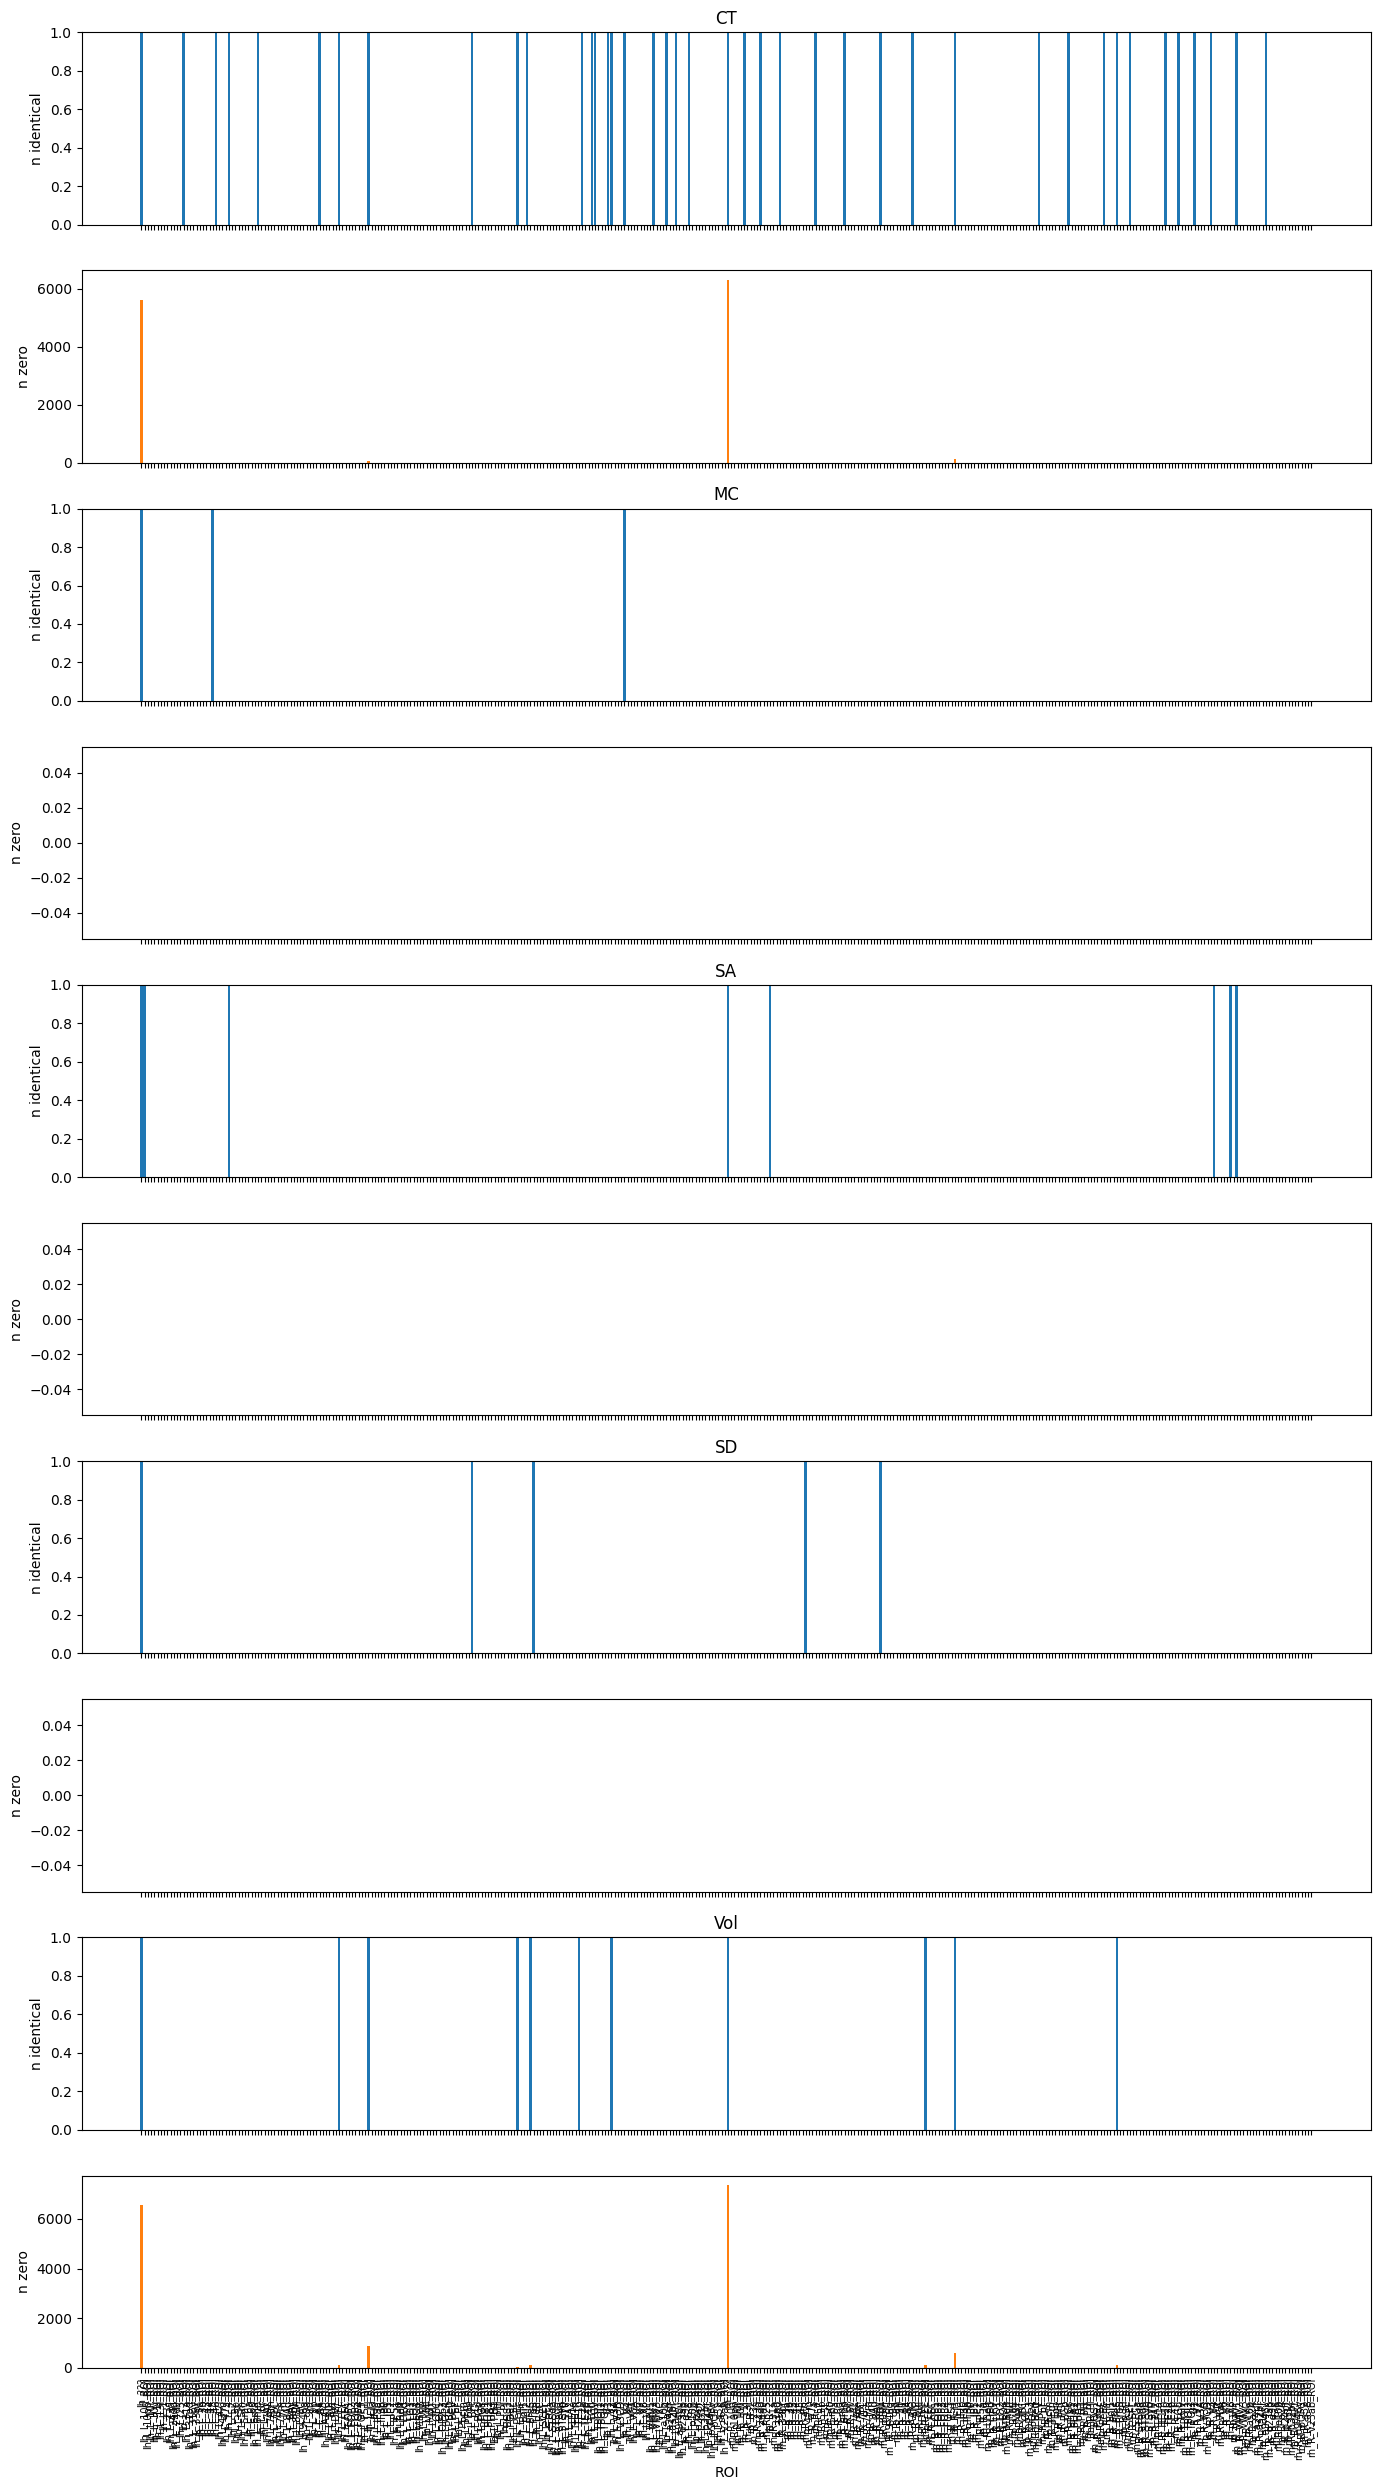

In [12]:
uniq = roi_qc['n_identical_values'].unstack('feature')
zero = roi_qc['n_zero_values'].unstack('feature')

rois = uniq.index.astype(str)
x = np.arange(len(rois))

n_feat = uniq.shape[1]
fig, axes = plt.subplots(2 * n_feat, 1, figsize=(14, 5 * n_feat), sharex=True)
axes = np.atleast_1d(axes)

for i, feat in enumerate(uniq.columns):
    ax_u, ax_z = axes[2 * i], axes[2 * i + 1]

    ax_u.bar(x, uniq[feat], color='tab:blue')
    ax_u.set_ylabel('n identical')
    ax_u.set_ylim(0, 1)
    ax_u.set_title(feat)

    ax_z.bar(x, zero[feat], color='tab:orange')
    ax_z.set_ylabel('n zero')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(rois, rotation=90, fontsize=7)
axes[-1].set_xlabel('ROI')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'roi.png'))
plt.show()

## Check full computation

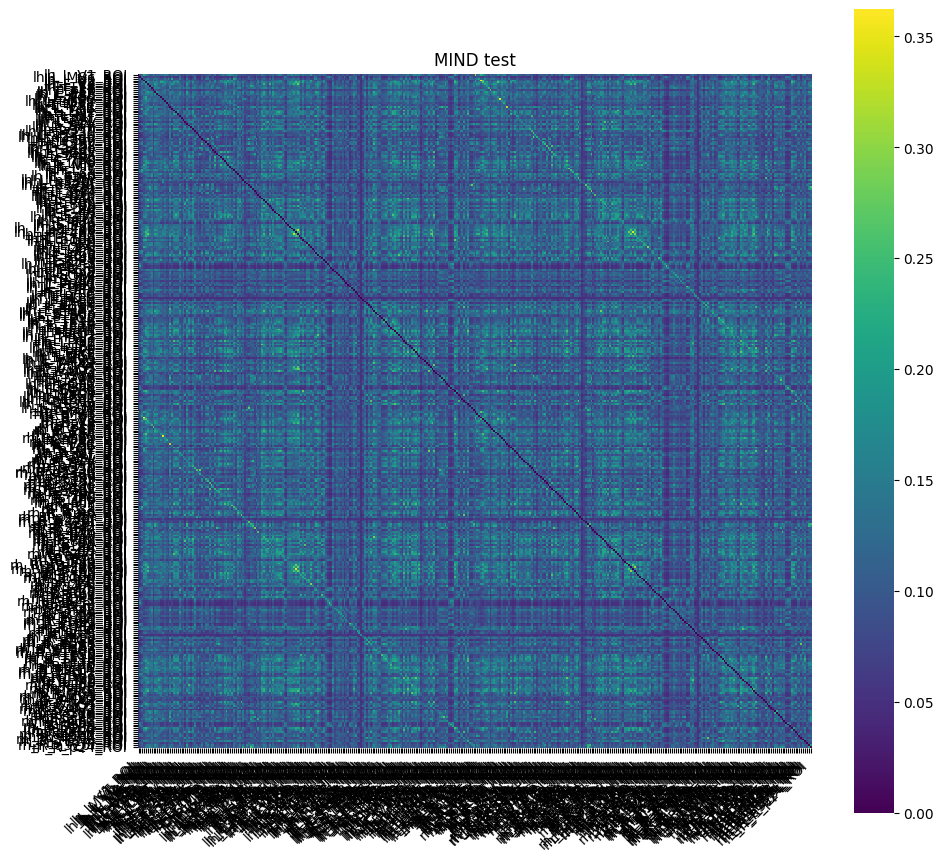

In [13]:
plt.figure(figsize=(10, 9))
sns.heatmap(MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()

## DWI DATA - check functions

In [14]:
# Path to FreeSurfer subject directory (needed for parcellation .annot files)
path_to_surf_dir = surf_dir

# Path to the vol2surf_DWI surface outputs for this subject
vol2surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "vol2surf_DWI", "surface")
tmp_dir = os.path.join(MAIN_DIR, 'tmp_mgz', 'mystery_man')

# DWI metrics available in vol2surf_DWI/surface/
features = {
    'FA':    'dti_FA_T1space_al2std60_back2sub',
    'MD':    'dti_MD_T1space_al2std60_back2sub',
    'ICVF':  'NODDI_ICVF_T1space_al2std60_back2sub',
    'ISOVF': 'NODDI_ISOVF_T1space_al2std60_back2sub',
    'OD':    'NODDI_OD_T1space_al2std60_back2sub',
}

feature_tuples = convert_to_mgz(tmp_dir,
                                vol2surf_dir,
                                path_to_surf_dir,
                                parcellation,
                                features)


  FA: ready
  MD: ready
  ICVF: ready
  ISOVF: ready
  OD: ready

Using 5 DWI features: ['FA', 'MD', 'ICVF', 'ISOVF', 'OD']
Found parcellation .annot files in /Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/label


In [15]:
feature_tuples

[('/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.FA.mgz',
  '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/rh.FA.mgz'),
 ('/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.MD.mgz',
  '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/rh.MD.mgz'),
 ('/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ICVF.mgz',
  '/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/rh.ICVF.mgz'),
 ('/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ISOVF.mgz',
  '/Users/skc48/Library/CloudStorage/O

In [22]:
DTI_MIND, qc_dataframe, roi_qc = compute_MIND(path_to_surf_dir, feature_tuples, parcellation, micro=True, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.FA.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.MD.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ICVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.ISOVF.mgz
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/tmp_mgz/mystery_man/lh.OD.mgz
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
features used: 
['Fea

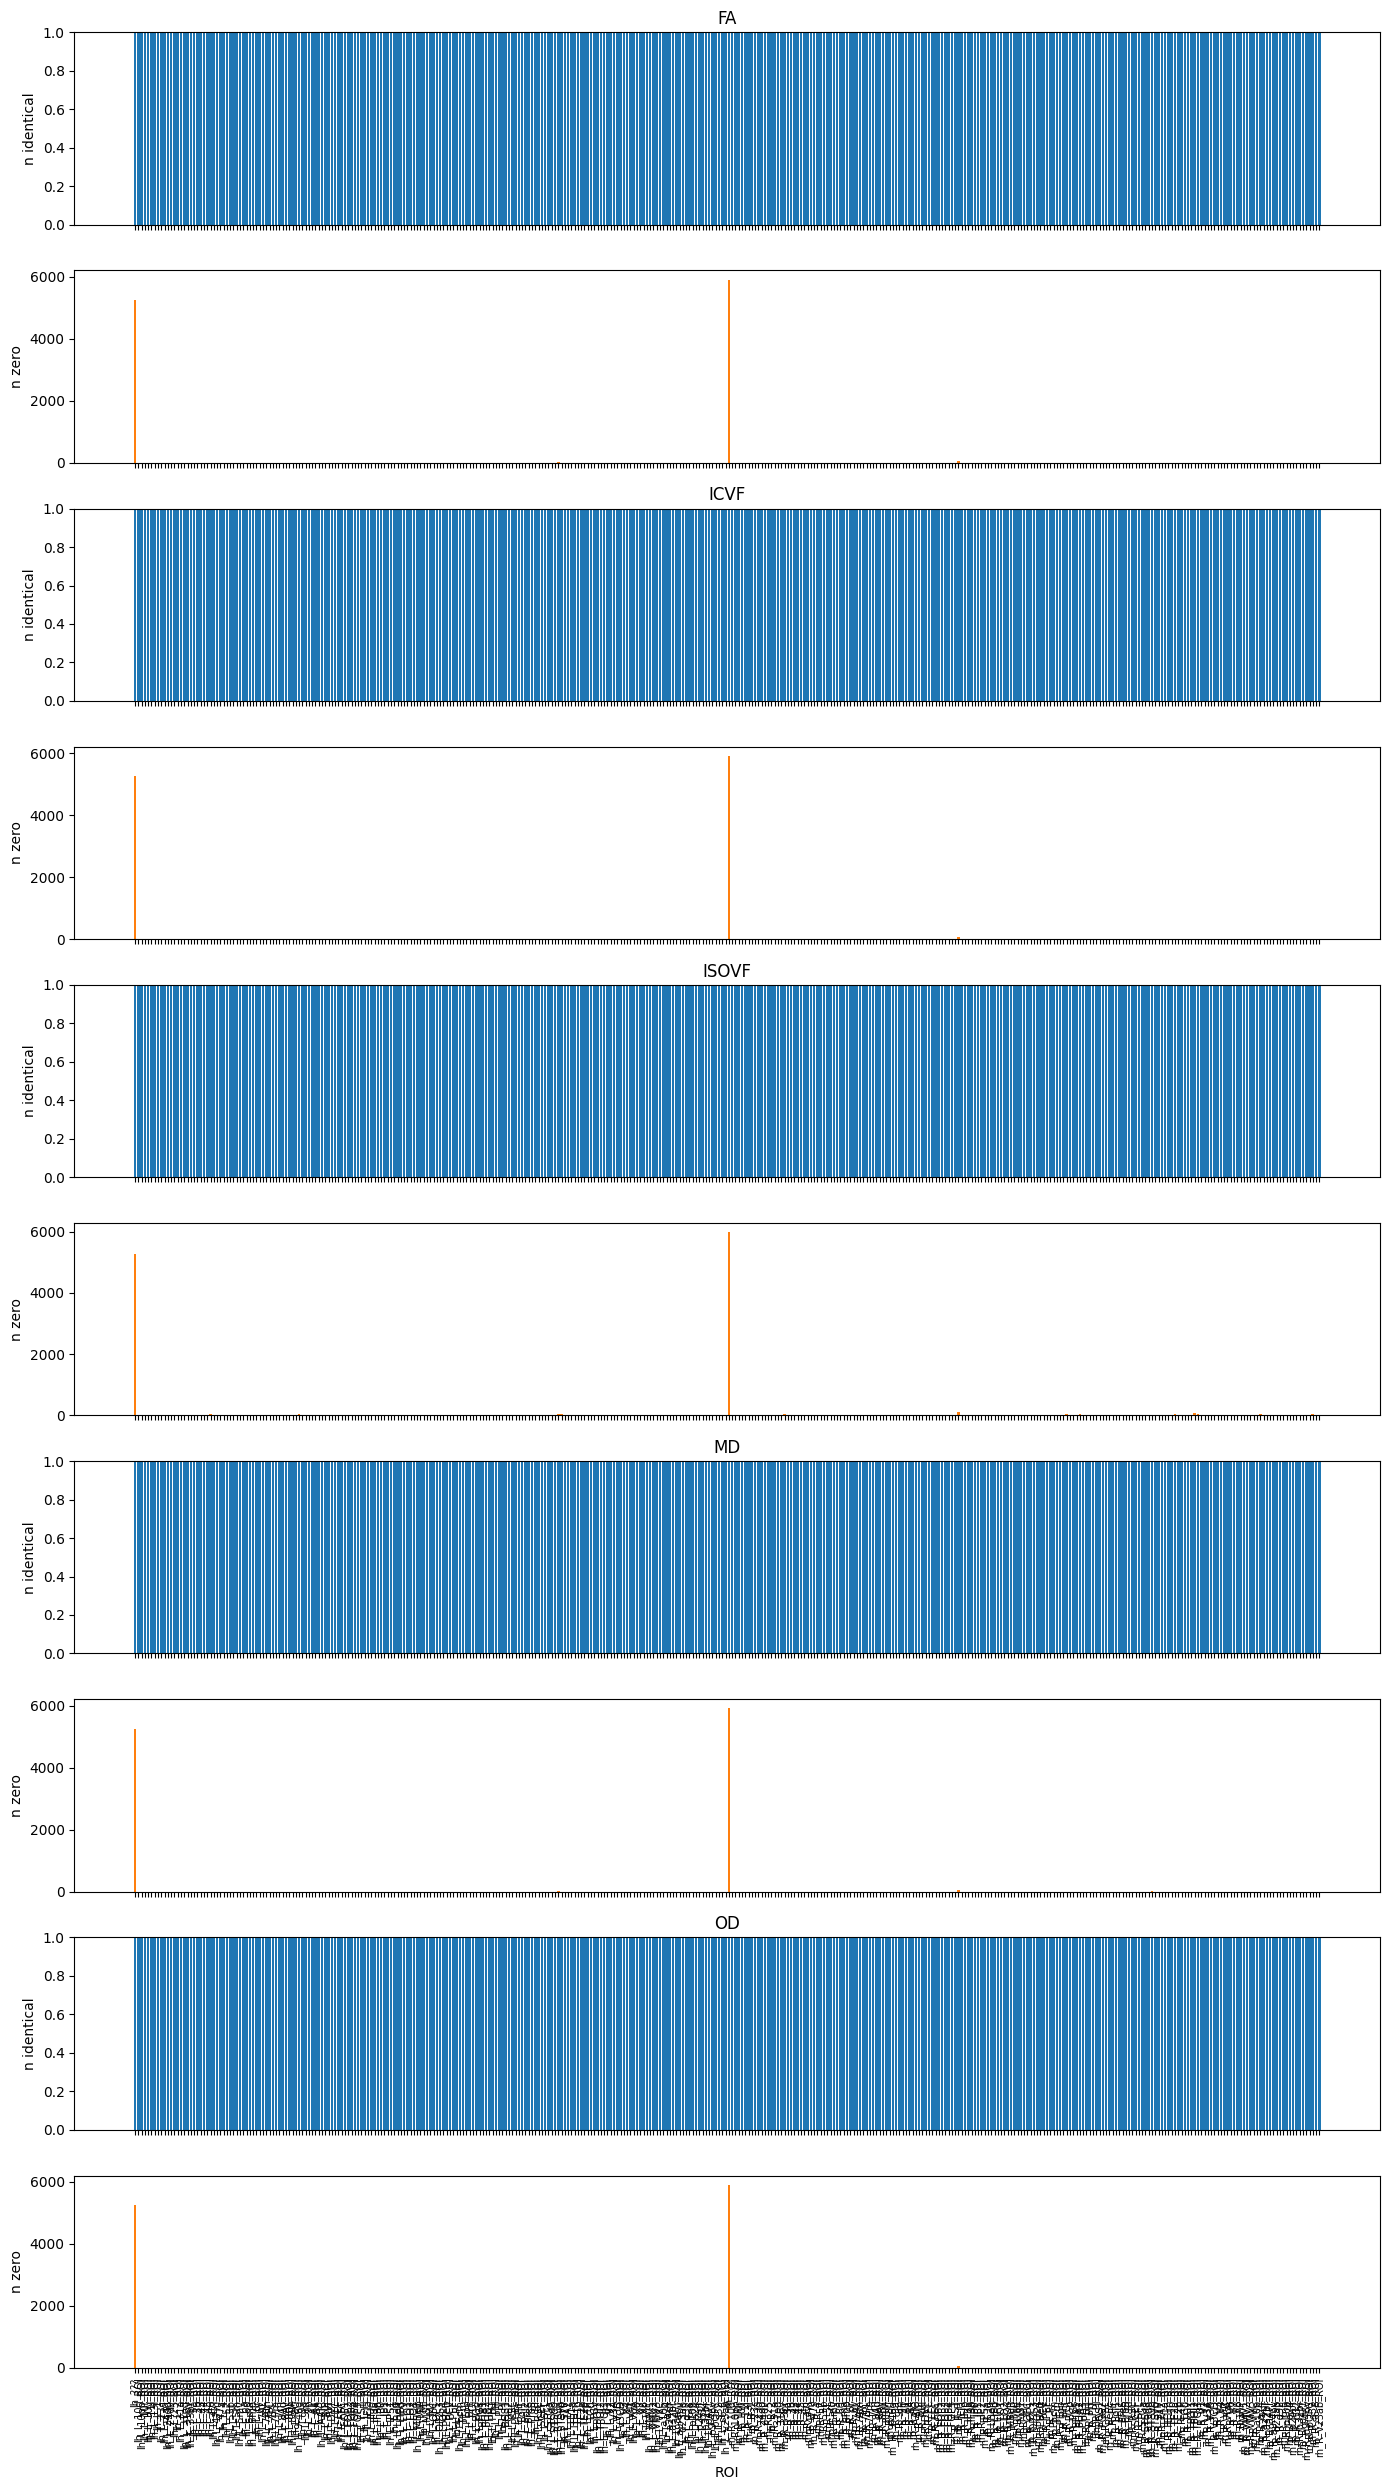

In [23]:
uniq = roi_qc['n_identical_values'].unstack('feature')
zero = roi_qc['n_zero_values'].unstack('feature')

rois = uniq.index.astype(str)
x = np.arange(len(rois))

n_feat = uniq.shape[1]
fig, axes = plt.subplots(2 * n_feat, 1, figsize=(14, 5 * n_feat), sharex=True)
axes = np.atleast_1d(axes)

for i, feat in enumerate(uniq.columns):
    ax_u, ax_z = axes[2 * i], axes[2 * i + 1]

    ax_u.bar(x, uniq[feat], color='tab:blue')
    ax_u.set_ylabel('n identical')
    ax_u.set_ylim(0, 1)
    ax_u.set_title(feat)

    ax_z.bar(x, zero[feat], color='tab:orange')
    ax_z.set_ylabel('n zero')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(rois, rotation=90, fontsize=7)
axes[-1].set_xlabel('ROI')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'DTI_roi.png'))
plt.show()

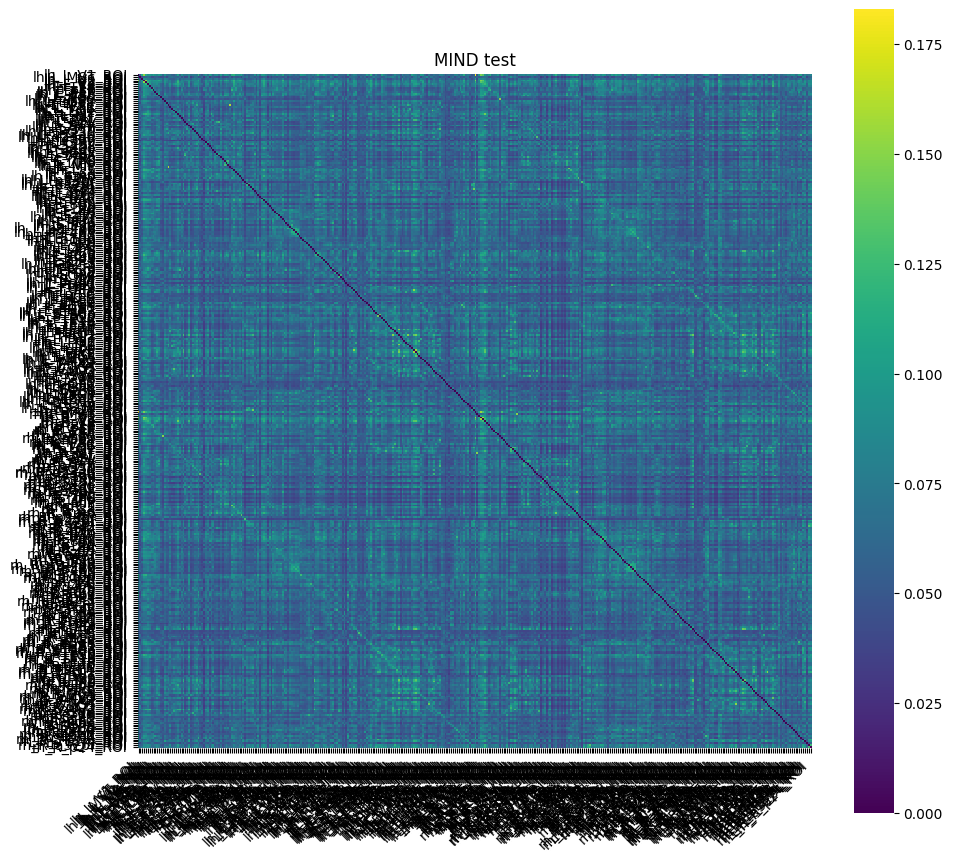

In [24]:
plt.figure(figsize=(10, 9))
sns.heatmap(DTI_MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()

# Check univariate MIND

In [25]:
UNI_MIND, qc_dataframe, roi_qc = compute_MIND(surf_dir, ["CT"], parcellation, resample=True, n_jobs=2, filter_vertices=False)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
['Feature_0']
0 Feature_0
rh
Loading right hemisphere data:
['Feature_0']
0 Feature_0
features used: 
['Feature_0']
Computing MIND...
Computing 64620 region pairs across 2 cores...
Done!
MIND computation: 149.6s


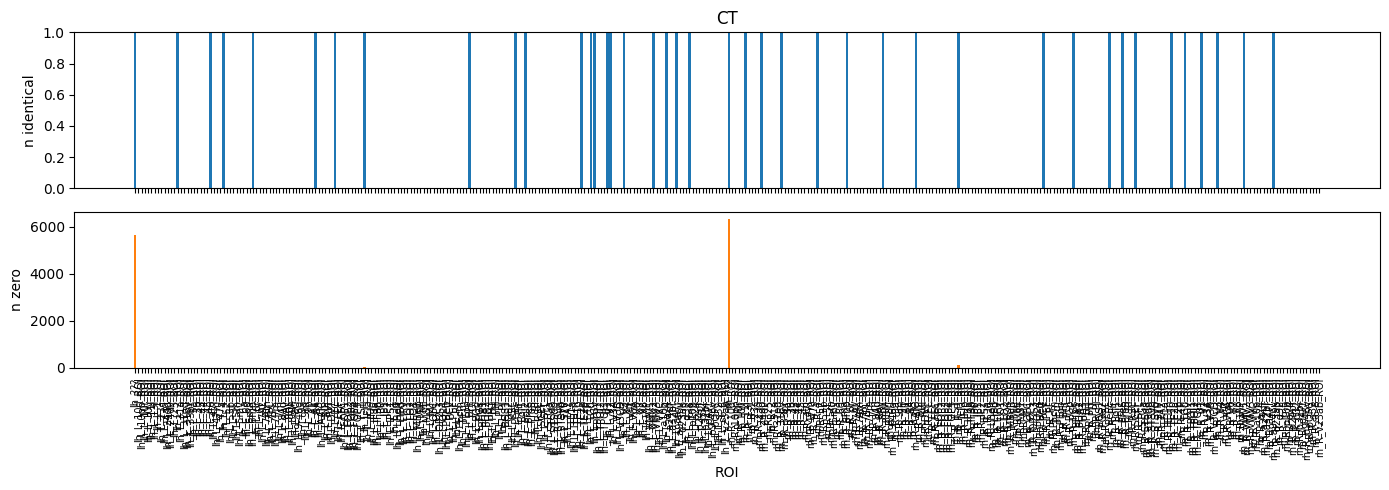

In [26]:
uniq = roi_qc['n_identical_values'].unstack('feature')
zero = roi_qc['n_zero_values'].unstack('feature')

rois = uniq.index.astype(str)
x = np.arange(len(rois))

n_feat = uniq.shape[1]
fig, axes = plt.subplots(2 * n_feat, 1, figsize=(14, 5 * n_feat), sharex=True)
axes = np.atleast_1d(axes)

for i, feat in enumerate(uniq.columns):
    ax_u, ax_z = axes[2 * i], axes[2 * i + 1]

    ax_u.bar(x, uniq[feat], color='tab:blue')
    ax_u.set_ylabel('n identical')
    ax_u.set_ylim(0, 1)
    ax_u.set_title(feat)

    ax_z.bar(x, zero[feat], color='tab:orange')
    ax_z.set_ylabel('n zero')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(rois, rotation=90, fontsize=7)
axes[-1].set_xlabel('ROI')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'UNI_roi.png'))
plt.show()

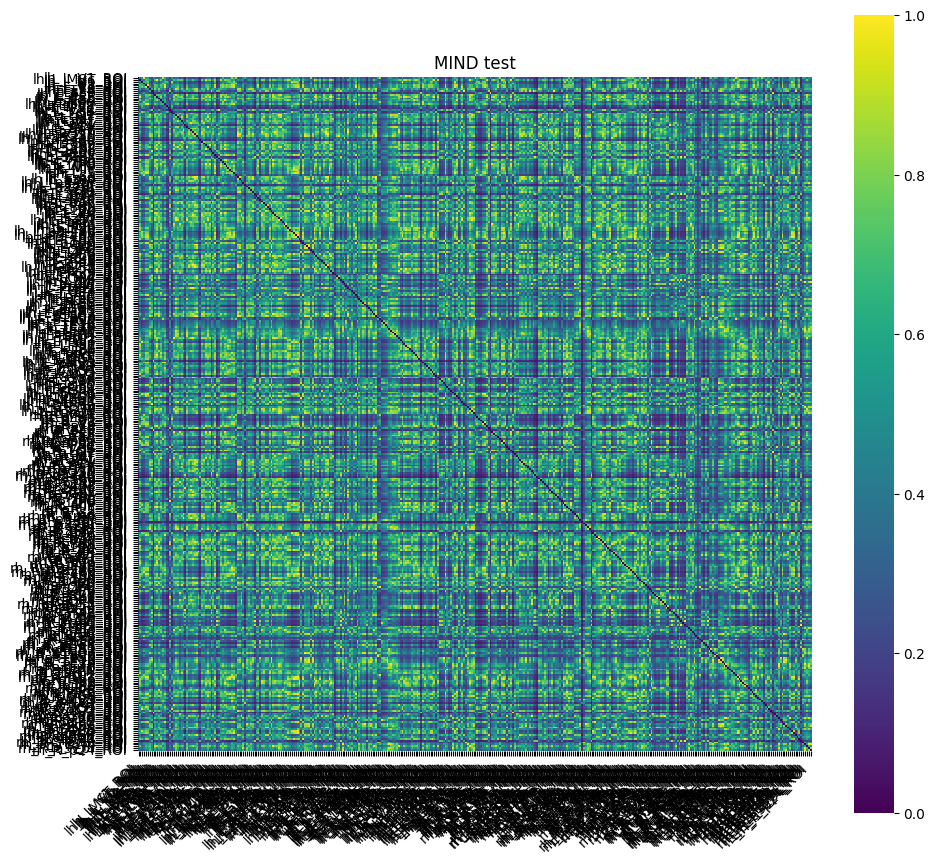

In [27]:
plt.figure(figsize=(10, 9))
sns.heatmap(UNI_MIND, xticklabels=True, yticklabels=True, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND test')
plt.tight_layout()
plt.show()